## Data import

In [1]:
# ===============================
# 1. Find projektets root korrekt
# ===============================
import sys
from pathlib import Path

cwd = Path.cwd()

# Gå op i mappestrukturen indtil vi finder enten 'data' eller 'CVACaseStudy'
while not ((cwd / "data").exists() or (cwd / "CVACaseStudy").exists()):
    if cwd.parent == cwd:
        raise RuntimeError("Kunne ikke finde projekt root")
    cwd = cwd.parent

PROJECT_ROOT = cwd
sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)


# ===============================
# 2. Imports
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor
from fdd.dataset import TimeSeriesDataset


# ===============================
# 3. Find data automatisk (ROBUST)
# ===============================
def find_file(root, filename):
    for path in root.rglob(filename):
        return path
    raise FileNotFoundError(f"{filename} not found in project")

DATA_PATH = find_file(PROJECT_ROOT, "FaultyCase1.mat")

print("DATA_PATH:", DATA_PATH)
print("Exists:", DATA_PATH.exists())


# ===============================
# 4. Load data
# ===============================
loader = DataLoader(DATA_PATH)
datasets = loader.load()

print("\nDatasets loaded:")
for name, ds in datasets.items():
    print(f"{name}: {ds.summary()}")


# ===============================
# 5. Fault info
# ===============================
fault_info = {
    "Set1_1": {"start": 1566, "end": 5181, "description": "Changing conditions"},
    "Set1_2": {"start": 657, "end": 3777, "description": "Steady-state 1"},
    "Set1_3": {"start": 691, "end": 3691, "description": "Steady-state 2"},
}


# ===============================
# 6. Quick test (valgfrit)
# ===============================
# Tjek at data virker
print("\nPreview:")
print(datasets["Set1_1"].sensors.head())

print("\nShape:")
print("Samples:", datasets["Set1_1"].n_samples)
print("Features:", datasets["Set1_1"].n_features)

PROJECT_ROOT: c:\Users\krist\OneDrive\Skrivebord\Fault detection\Fault-detection-project\Fault-detection-project
DATA_PATH: c:\Users\krist\OneDrive\Skrivebord\Fault detection\Fault-detection-project\Fault-detection-project\data\FaultyCase1.mat
Exists: True

Datasets loaded:
Set1_1: TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)
Set1_2: TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)
Set1_3: TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)

Preview:
   Air_Delivery_P  P_Bottom_Riser  P_Top_Riser  P_Top_Separator  \
0        0.123671        0.118994     0.099840         0.102702   
1        0.123146        0.118504     0.099780         0.102566   
2        0.122749        0.118401     0.099980         0.102515   
3        0.122648        0.118266     0.100266         0.102741   
4        0.122463        0.117908     0.100248         0.103059   

   P_3Phase_Separator  Diff_P_Riser  Diff_P_VC404  Air_In_Flow  Water_In_Flow  \
0            0.099423

In [2]:
for name, dataset in datasets.items():
    print(dataset.summary())
    display(dataset.sensors.head())

TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.123671,0.118994,0.099840,0.102702,0.099423,0.019198,0.248773,0.020653,0.493771,-0.246817,...,995.862488,996.525513,20.018761,20.923019,21.754801,7.324118,21.015640,46.294441,28.072460,2.1050
1,0.123146,0.118504,0.099780,0.102566,0.099522,0.018732,0.288827,0.020645,0.493793,-0.246817,...,995.862610,996.518677,20.015230,20.922810,21.761770,7.321606,21.023270,46.311249,28.073271,2.0150
2,0.122749,0.118401,0.099980,0.102515,0.099621,0.018358,0.270946,0.020638,0.493816,-0.246818,...,995.862793,996.511780,20.011700,20.922609,21.768749,7.319094,21.035440,46.328072,28.074089,1.9175
3,0.122648,0.118266,0.100266,0.102741,0.099721,0.018015,0.240905,0.020636,0.493838,-0.246819,...,995.862976,996.505005,20.008169,20.922409,21.775721,7.316582,21.047621,46.344879,28.074909,1.9150
4,0.122463,0.117908,0.100248,0.103059,0.099792,0.017672,0.271661,0.020635,0.493860,-0.246819,...,995.863098,996.498230,20.004641,20.922199,21.782700,7.314071,21.059790,46.361698,28.075729,2.1375


TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.134422,0.128272,0.102251,0.104552,0.099477,0.026017,0.395401,0.041172,1.988174,0.345307,...,987.024170,997.685425,20.788589,19.79677,19.106760,35.205521,27.12253,88.334503,43.250599,2.2100
1,0.134377,0.128434,0.102302,0.104471,0.099487,0.026034,0.470502,0.041136,1.989220,0.128820,...,987.656128,997.685486,20.789459,19.79862,18.965611,35.207569,27.11714,88.385307,43.258072,2.2900
2,0.134632,0.128661,0.102409,0.104656,0.099497,0.026203,0.429733,0.041123,1.992013,0.014496,...,988.288086,997.685486,20.790331,19.80048,18.918560,35.209610,27.11174,88.436111,43.265541,2.1000
3,0.134634,0.128690,0.102516,0.104800,0.099507,0.026164,0.316007,0.041084,1.994807,0.458081,...,988.919983,997.685486,20.791210,19.80234,18.918560,35.211651,27.10635,88.486923,43.273010,1.9975
4,0.134763,0.128653,0.102623,0.104902,0.099517,0.026040,0.292404,0.041065,1.997600,0.412542,...,989.552002,997.685608,20.792080,19.80419,18.918560,35.213699,27.10095,88.537727,43.280479,2.1775


TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.148614,0.144112,0.099908,0.102331,0.099692,0.044019,0.657899,0.021139,3.493562,-0.119259,...,278.099609,998.15802,21.240061,21.056549,20.549940,34.029011,20.176050,47.243179,56.314251,2.4075
1,0.148712,0.144223,0.099980,0.102346,0.099749,0.044139,0.664337,0.021129,3.493410,-0.204256,...,274.954712,998.15802,21.240170,21.055470,20.549940,34.016430,20.188910,47.229820,56.316959,2.4150
2,0.148811,0.144334,0.100075,0.102346,0.099805,0.044162,0.675781,0.021120,3.493258,-0.246815,...,278.543915,998.15802,21.240280,21.054399,20.549940,34.003399,20.201780,47.216461,56.319679,2.3925
3,0.148909,0.144444,0.100153,0.102410,0.099861,0.044153,0.700099,0.021112,3.493105,-0.122358,...,280.331696,998.15802,21.240391,21.053320,20.597019,33.990379,20.214649,47.203110,56.322392,2.4950
4,0.149008,0.144440,0.100224,0.102479,0.099917,0.044143,0.709398,0.021104,3.492953,-0.041533,...,285.598602,998.15802,21.240490,21.052250,20.612711,33.977360,20.227510,47.189751,56.325100,2.5000


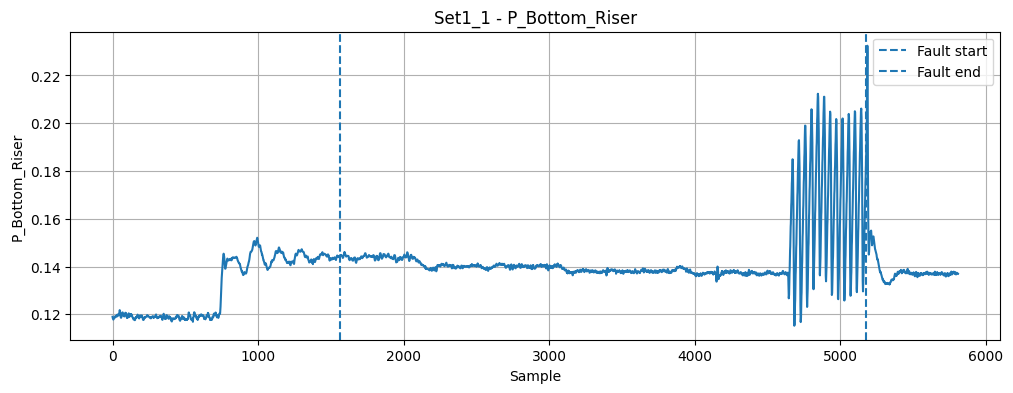

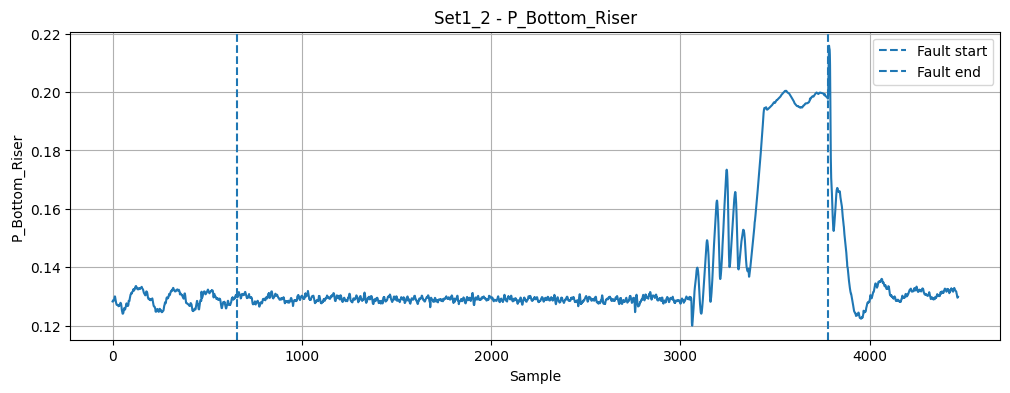

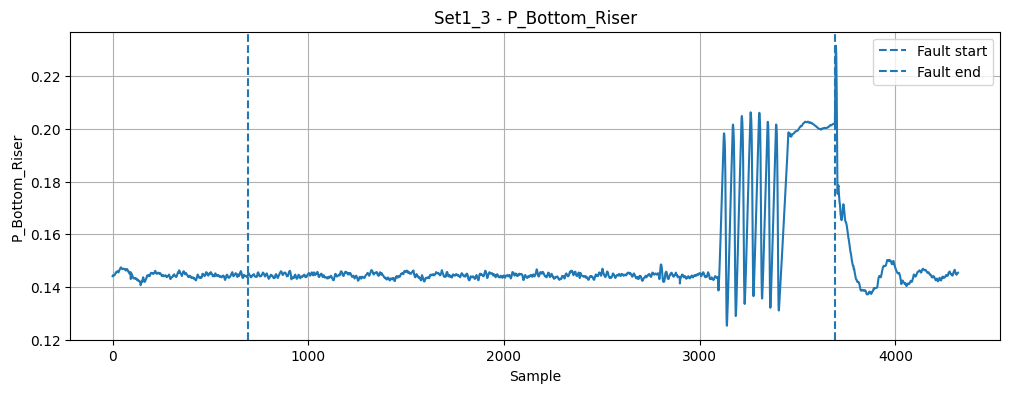

In [3]:
sensor = "P_Bottom_Riser"

for name, dataset in datasets.items():
    plt.figure(figsize=(12, 4))
    plt.plot(dataset.sensors[sensor])
    plt.axvline(fault_info[name]["start"], linestyle="--", label="Fault start")
    plt.axvline(fault_info[name]["end"], linestyle="--", label="Fault end")
    plt.title(f"{name} - {sensor}")
    plt.xlabel("Sample")
    plt.ylabel(sensor)
    plt.grid(True)
    plt.legend()
    plt.show()

## Train on healthy data

Vi bruger TimeSeriesDataset-klassen til at lave et samlet healthy træningsdatasæt

In [4]:
healthy_parts = []

for name, dataset in datasets.items():
    start = fault_info[name]["start"]
    healthy_parts.append(dataset.subset_rows(0, start).sensors)

healthy_sensors = pd.concat(healthy_parts, ignore_index=True)

healthy_dataset = TimeSeriesDataset(
    name="Healthy_training_data",
    sensors=healthy_sensors,
    metadata={"description": "All samples before fault start"},
)

## Using Preprocessor class

Her bruges StandardPreprocessor, så standardisering ikke lænhere ligger direkte i notebooken

In [5]:
preprocessor = StandardPreprocessor(
    with_standardization=True,
    n_lags=0,
    drop_na=True,
)

healthy_scaled = preprocessor.fit_transform(healthy_dataset)

X_train = healthy_scaled.to_numpy()

## Train PCA 

PCA lærer den normale multivariate sammenhæng mellem sensorene

In [6]:
cov_matrix = np.cov(X_train.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = eigenvalues.argsort()[::-1]
eigenvalues = np.real(eigenvalues[idx])
eigenvectors = np.real(eigenvectors[:, idx])

n_components = 7
P = eigenvectors[:, :n_components]
lambda_inv = np.diag(1 / eigenvalues[:n_components])

## Hotelling T2

Kontrolgrænsen for PCA-modellen

In [7]:
from scipy.stats import f

n = X_train.shape[0]
a = n_components
alpha = 0.05

F_limit = f.ppf(1 - alpha, a, n - a)
T2_limit = (a * (n - 1) * (n + 1)) / (n * (n - a)) * F_limit

T2_limit

np.float64(14.123018031348115)

## PCA detection

Hvis T2 bliver større end grænsen, betragtes observationen som unormal

In [8]:
def pca_detect(dataset):
    dataset_scaled = preprocessor.transform(dataset)
    X = dataset_scaled.to_numpy()

    scores = X @ P
    T2 = np.sum((scores @ lambda_inv) * scores, axis=1)

    alarm = T2 > T2_limit
    return T2, alarm